In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Hotel_A_train.xlsx')
df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,36849376,M,30,Asian American,Mid-School,25K --50K,North,Resort,"Saturday, August 22, 2015","Sunday, August 23, 2015",...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,199
1,87596032,F,57,caucasian,College,50K -- 100K,South,Resort,"Wednesday, May 25, 2016","Friday, May 27, 2016",...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,228
2,77180040,F,49,caucasian,Mid-School,50K -- 100K,West,City Hotel,"Thursday, May 26, 2016","Friday, May 27, 2016",...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,170
3,41192187,F,63,Latino,Mid-School,<25K,East,City Hotel,"Thursday, December 22, 2016","Sunday, December 25, 2016",...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,196
4,44395324,F,52,caucasian,Mid-School,50K -- 100K,North,City Hotel,"Thursday, June 2, 2016","Saturday, June 4, 2016",...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,166


In [ ]:
#Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

In [ ]:
df.shape

(27499, 24)

In [ ]:
#missing value check
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749900e+04,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000
mean,5.016461e+07,43.977454,2.333576,1.743882,0.351540,12.495182,175.136478
std,2.886911e+07,15.303148,1.176526,0.721972,0.573326,11.206036,43.877087
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.523943e+07,31.000000,2.000000,1.000000,0.000000,5.000000,137.000000
50%,5.014996e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000
75%,7.518288e+07,57.000000,3.000000,2.000000,1.000000,20.000000,214.000000
max,9.999900e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


In [ ]:
df['Reservation_Status'].unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

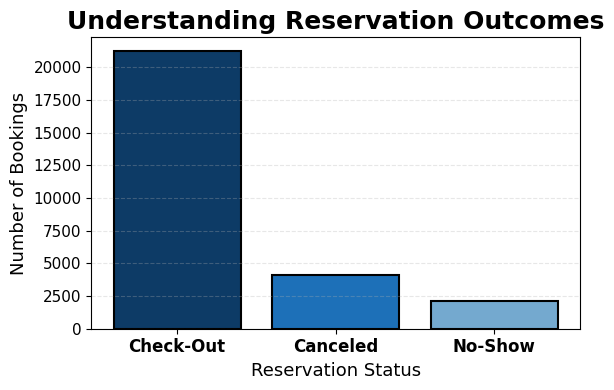

In [ ]:


# Count reservation outcomes
status_counts = df['Reservation_Status'].value_counts()

# Reorder if needed, correcting the spelling of 'Canceled'
order = ['Check-Out', 'Canceled', 'No-Show']
status_counts = status_counts.reindex(order)

# Colors
colors = ['#0D3B66', '#1D70B8', '#74A9CF']
# Create figure
plt.figure(figsize=(6, 4))
bars = plt.bar(status_counts.index, status_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Title and labels
plt.title('Understanding Reservation Outcomes', fontsize=18, fontweight='bold')
plt.xlabel('Reservation Status', fontsize=13)
plt.ylabel('Number of Bookings', fontsize=13)

# Add values and percentages on bars
total = status_counts.sum()
for bar in bars:
    height = bar.get_height()



# Style
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

In [ ]:
#df = df[df['Lead_Time'] >= 0]
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Booking_date'] = pd.to_datetime(df['Booking_date'])

In [ ]:
#Create Lead_Time Column
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

In [ ]:
#Check the New Column
df[['Booking_date','Expected_checkin','Lead_Time']].head()

,Booking_date,Expected_checkin,Lead_Time
0,2015-04-14,2015-08-22,130
1,2016-03-30,2016-05-25,56
2,2016-01-11,2016-05-26,136
3,2016-10-24,2016-12-22,59
4,2015-10-29,2016-06-02,217


In [ ]:
#Check Negative Values
df[df['Lead_Time'] < 0]

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate,Lead_Time
26,19540411,M,38,Asian American,High-School,50K -- 100K,North,City Hotel,2017-02-04,"Wednesday, February 8, 2017",...,No,No,No Deposit,Online,Yes,Check-Out,No,0,106,-3
56,6574848,F,22,African American,High-School,25K --50K,South,Airport Hotels,2017-06-03,"Wednesday, June 7, 2017",...,No,No,No Deposit,Online,Yes,Check-Out,No,0,247,-2
65,33672300,M,51,Asian American,Grad,25K --50K,East,Airport Hotels,2015-09-30,"Friday, October 2, 2015",...,No,No,No Deposit,Online,Yes,Check-Out,No,0,144,-2
167,22975448,M,65,African American,Mid-School,<25K,East,Airport Hotels,2016-02-15,"Thursday, February 18, 2016",...,No,No,No Deposit,Online,Yes,Check-Out,Yes,30,102,-3
277,3388009,M,40,African American,Mid-School,25K --50K,East,Resort,2016-08-30,"Wednesday, August 31, 2016",...,No,No,No Deposit,Online,Yes,Check-Out,Yes,15,211,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26983,819588,F,57,caucasian,Grad,25K --50K,East,City Hotel,2015-11-30,"Friday, December 4, 2015",...,No,No,No Deposit,Agent,No,Canceled,Yes,25,222,-3
27014,28751616,M,57,African American,College,25K --50K,North,City Hotel,2016-05-10,"Friday, May 13, 2016",...,Yes,Yes,No Deposit,Agent,Yes,Canceled,Yes,10,198,-2
27333,22318084,F,48,African American,Grad,25K --50K,South,City Hotel,2015-06-09,"Saturday, June 13, 2015",...,Yes,No,No Deposit,Online,Yes,Canceled,Yes,40,244,-1
27418,23219836,M,45,Asian American,College,25K --50K,South,Resort,2015-01-21,"Saturday, January 24, 2015",...,No,No,No Deposit,Online,Yes,Canceled,Yes,10,113,-1


In [ ]:
df['Lead_Time'].describe()

,Lead_Time
count,27499.000000
mean,109.910906
std,78.048838
min,-4.000000
25%,45.000000
50%,101.000000
75%,166.000000
max,708.000000


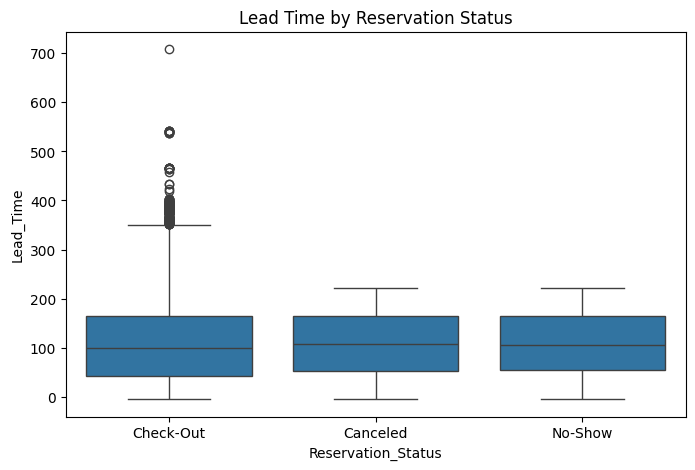

In [ ]:
#Lead Time vs Reservation Status (before)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Reservation_Status', y='Lead_Time', data=df)
plt.title('Lead Time by Reservation Status')
plt.show()

In [ ]:
#Remove Negative Lead Time
df = df[df['Lead_Time'] >= 0]

In [ ]:
#Check Distribution
df['Lead_Time'].describe()

,Lead_Time
count,26993.000000
mean,112.003149
std,77.252151
min,0.000000
25%,48.000000
50%,103.000000
75%,167.000000
max,708.000000


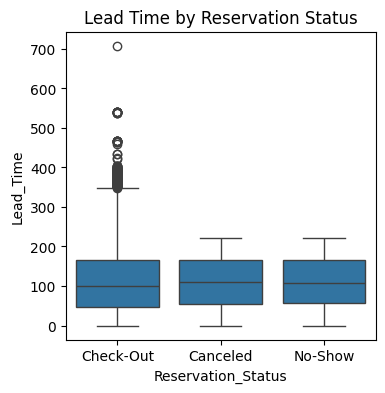

In [ ]:
#Hotel Type vs Reservation Status (after)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
sns.boxplot(x='Reservation_Status', y='Lead_Time', data=df)
plt.title('Lead Time by Reservation Status')
plt.show()


In [ ]:
import plotly.express as px

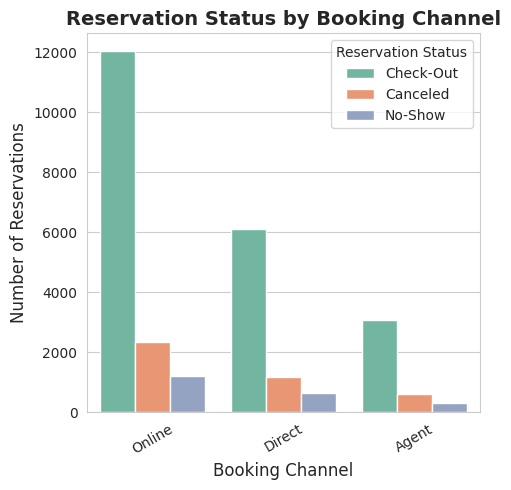

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))

sns.countplot(
    data=df,
    x='Booking_channel',
    hue='Reservation_Status',
    palette='Set2'
)

plt.title('Reservation Status by Booking Channel', fontsize=14, fontweight='bold')
plt.xlabel('Booking Channel', fontsize=12)
plt.ylabel('Number of Reservations', fontsize=12)

plt.xticks(rotation=30)
plt.legend(title='Reservation Status')

plt.tight_layout()
plt.show()

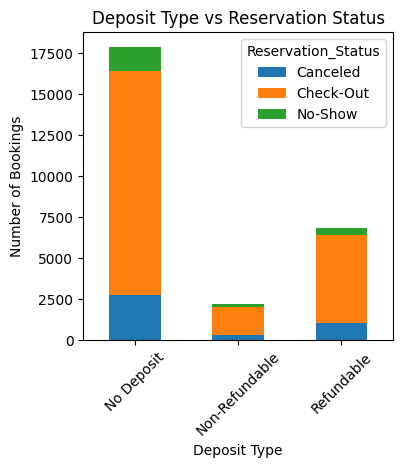

In [ ]:
deposit_status = pd.crosstab(df['Deposit_type'], df['Reservation_Status'])

deposit_status.plot(kind='bar', stacked=True, figsize=(4,4))
plt.title("Deposit Type vs Reservation Status")
plt.xticks(rotation=45)
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")
plt.show()

In [ ]:
df['Use_Promotion'].value_counts()

,count
Use_Promotion,
Yes,20284
No,6709


In [ ]:
df['Use_Promotion'].value_counts(normalize=True) * 100

,proportion
Use_Promotion,
Yes,75.145408
No,24.854592


In [ ]:
df['Discount_Rate'].describe()

,Discount_Rate
count,26993.000000
mean,12.495277
std,11.210546
min,0.000000
25%,5.000000
50%,10.000000
75%,20.000000
max,40.000000


In [ ]:
df['Discount_Rate'].describe()

,Discount_Rate
count,26993.000000
mean,12.495277
std,11.210546
min,0.000000
25%,5.000000
50%,10.000000
75%,20.000000
max,40.000000


In [ ]:
numerical_df = df.select_dtypes(include=['int64','float64'])

In [ ]:
corr_matrix = numerical_df.corr()

# **Revenue Loss Estimation**

In [ ]:
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])

df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

In [ ]:
df['Revenue'] = df['Room_Rate'] * df['Length_of_Stay']

In [ ]:
revenue_by_status = df.groupby('Reservation_Status')['Revenue'].sum()

print(revenue_by_status)

Reservation_Status
Canceled     1313782
Check-Out    6647399
No-Show       671677
Name: Revenue, dtype: int64


In [ ]:
revenue_loss = revenue_by_status['Canceled'] + revenue_by_status['No-Show']

print("Estimated Revenue Loss:", revenue_loss)

Estimated Revenue Loss: 1985459


In [ ]:
revenue_by_status = df.groupby('Reservation_Status')['Revenue'].sum()

revenue_loss = revenue_by_status.loc[['Canceled','No-Show']].sum()

total_revenue = revenue_by_status.sum()

loss_percentage = (revenue_loss / total_revenue) * 100

print("Revenue Loss Percentage:", round(loss_percentage,2), "%")

Revenue Loss Percentage: 23.0 %


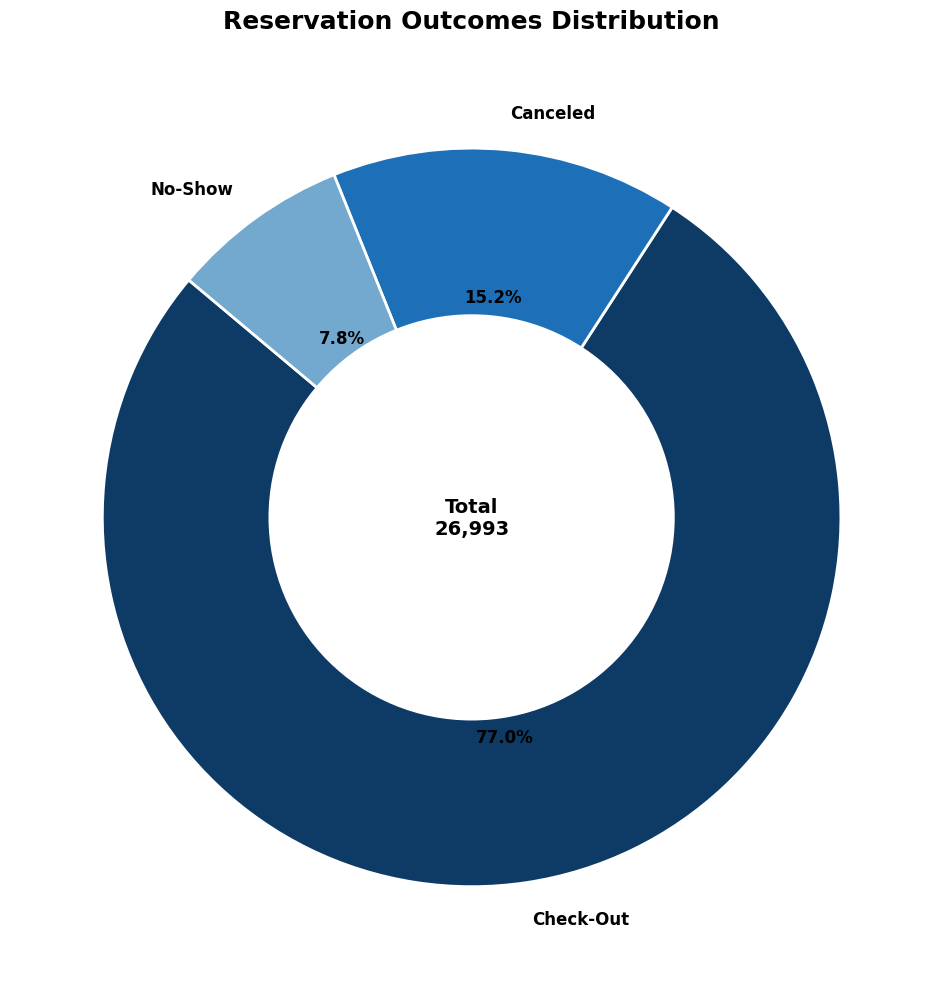

In [ ]:
# Count reservation outcomes
status_counts = df['Reservation_Status'].value_counts()

# Ensure order
order = ['Check-Out', 'Canceled', 'No-Show']
status_counts = status_counts.reindex(order)

# Blue shades (professional gradient)
colors = ['#0D3B66', '#1D70B8', '#74A9CF']

# Create figure
plt.figure(figsize=(10,10))

# Pie chart
wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=['Check-Out', 'Canceled', 'No-Show'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Donut effect (makes it more modern)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Title
plt.title('Reservation Outcomes Distribution', fontsize=18, fontweight='bold', pad=20)

# Add total in center
total = status_counts.sum()
plt.text(0, 0, f'Total\n{int(total):,}', ha='center', va='center',
         fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_206/3588687715.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




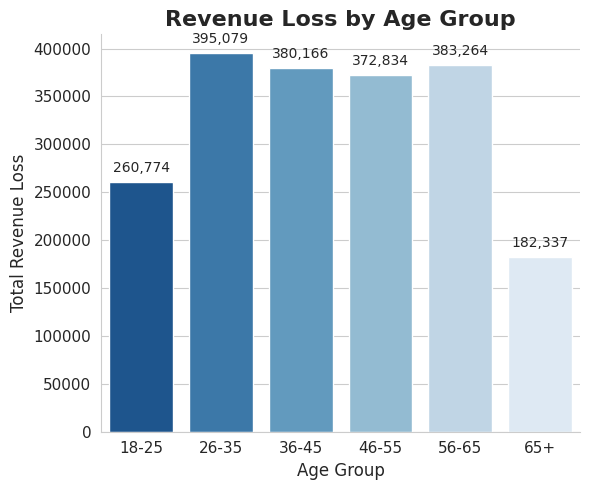

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate revenue
df['Revenue'] = df['Room_Rate'] * df['Length_of_Stay']

# Revenue loss occurs for Cancelled and No-Show reservations
loss_df = df[df['Reservation_Status'].isin(['Canceled', 'No-Show'])].copy()

# Create age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
loss_df['Age_Group'] = pd.cut(loss_df['Age'], bins=bins, labels=labels)

# Calculate revenue loss by age group
age_loss = loss_df.groupby('Age_Group', observed=False)['Revenue'].sum().reset_index()

# Sort just in case
age_loss['Age_Group'] = pd.Categorical(age_loss['Age_Group'], categories=labels, ordered=True)
age_loss = age_loss.sort_values('Age_Group')

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=age_loss,
    x='Age_Group',
    y='Revenue',
    palette='Blues_r'
)

# Titles and labels
plt.title('Revenue Loss by Age Group', fontsize=16, weight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Revenue Loss', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )

# Remove extra borders
sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_206/3388346900.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




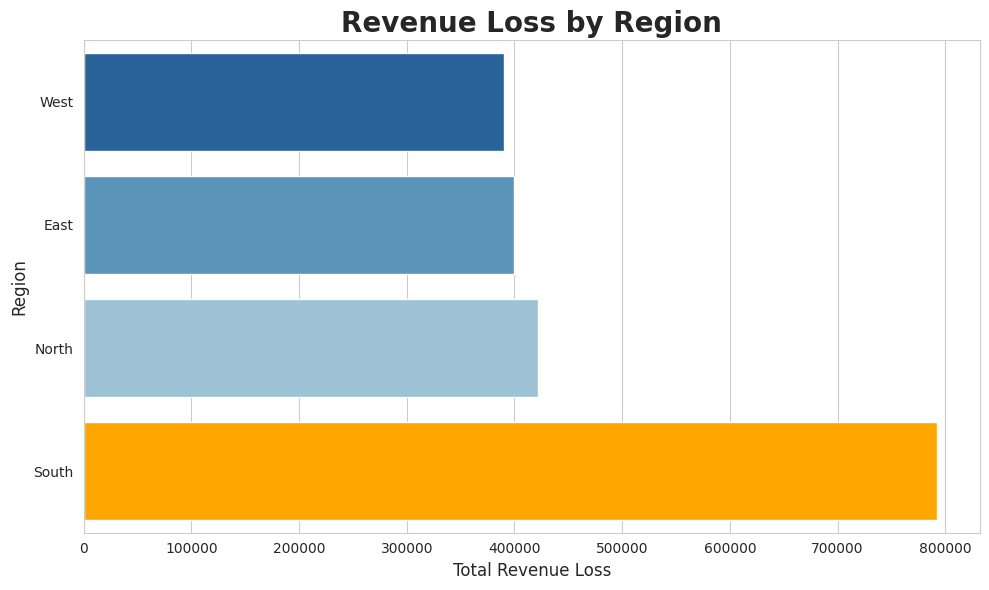

In [ ]:

# Create revenue column
df["Revenue"] = df["Room_Rate"] * df["Length_of_Stay"]

# Filter only cancelled and no-show bookings
loss_df = df[df["Reservation_Status"].isin(["Canceled", "No-Show"])]

# Group by region and calculate total revenue loss
region_loss = (
    loss_df.groupby("Country_region")["Revenue"]
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=region_loss,
    y="Country_region",
    x="Revenue",
    palette="Blues_r"
)

# Highlight highest region
max_index = region_loss["Revenue"].idxmax()
bars = plt.gca().patches
bars[max_index].set_facecolor("orange")

plt.title("Revenue Loss by Region", fontsize=20, weight="bold")
plt.xlabel("Total Revenue Loss", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.tight_layout()
plt.show()